In [28]:
import sys
import argparse
import math
import random
import numpy as np

from population import Population
from pulsar import Pulsar
from survey_new import Survey
import orbital_degradation

import pandas as pd
import pickle

if sys.version_info[0] < 3:
    import cPickle
else:
    import pickle as cPickle


def loadModel(popfile='pulsarpop.pkl', popmodel=None):
    """Loads in either a model from disk (popfile, cPickle),
       or pass in a model from memory (popmodel)"""

    if popmodel is None:

        with open(popfile, "rb") as f:
            pop = pickle.load(f)

        print("Loaded", len(pop.population), "pulsars")
    #else:
       # pop = popmodel

    return pop

class Detections:
    """Just a simple object to store survey detection summary"""
    def __init__(self,
                 ndet=None,
                 ndisc=None,
                 nsmear=None,
                 nout=None,
                 nbr=None,
                 ntf=None):
        self.ndet = ndet
        self.ndisc = ndisc
        self.nsmear = nsmear
        self.nout = nout
        self.nbr = nbr
        self.nfaint = ntf

def run(pop,
        surveyList,
        nostdout=False,
        allsurveyfile=True,
        scint=False,
        compute_degfac=False,
        accelsearch=False,
        jerksearch=False,
        rratssearch=False,loadmodel=False):

    """Run the surveys and detect the pulsars."""
    if loadmodel:
        pop = loadModel(popfile='pulsarpop.pkl')
    else:
        pop=pop
    if not nostdout:
        print("Running doSurvey on population...")
        print(pop)

    surveyPops = []

    for surv in surveyList:

        s = Survey(surv)
        s.discoveries = 0

        if not nostdout:
            print("\nRunning survey {0}".format(surv))

        survpop = Population()

        # Counters
        nsmear = 0
        nout = 0
        ntf = 0
        ndet = 0
        nbr = 0
            
        #evo only gives you alive pulsars
        alive = [psr for psr in pop.population]

        t_obs = s.tobs
        # Calculate S/N for entire population
        snr = s.SNRcalc_new(
            alive,
            pop,
            accelsearch=accelsearch,
            jerksearch=jerksearch,
            rratssearch=rratssearch
        )

        snr_arr = np.asarray(snr, dtype=float).copy()

        valid = snr_arr > 0
        
        if compute_degfac:
        
            if accelsearch:
                _, gamma = compute_population_degradation(alive,tobs=t_obs,order=2)
        
            elif jerksearch:
                _, gamma = compute_population_degradation(alive,tobs=t_obs,order=3)
        
            else:
                _, gamma = compute_population_degradation(alive,tobs=t_obs,order=1)
                #print(gamma)
            
            gamma = np.asarray(gamma, dtype=float)
        
            snr_arr[valid] *= gamma[valid]**2

       

        for psr, snr_val in zip(alive, snr_arr):

            # Apply scintillation if enabled
            if scint and snr_val > 0:
                snr_val = s.scint(psr, snr_val)

            # Detected pulsar
            if snr_val > s.SNRlimit:

                ndet += 1

                psr.snr = snr_val
                survpop.population.append(psr)

                # Count discoveries only once
                if not psr.detected:
                    psr.detected = True
                    s.discoveries += 1

            # Not detected categories
            elif snr_val == -1.0:
                nsmear += 1

            elif snr_val == -2.0:
                nout += 1

            elif snr_val == -3.0:
                nbr += 1

            else:
                ntf += 1


        if not nostdout:

            print(
                "Total pulsars in model = {0}".format(
                    len(pop.population)
                )
            )

            print(
                "Number detected by survey {0} = {1}".format(
                    surv,
                    ndet
                )
            )

            print(
                "Of which are discoveries = {0}".format(
                    s.discoveries
                )
            )

            print(
                "Number too faint = {0}".format(
                    ntf
                )
            )

            print(
                "Number smeared = {0}".format(
                    nsmear
                )
            )

            print(
                "Number out = {0}".format(
                    nout
                )
            )

            if rratssearch:
                print(
                    "Number didn't burst = {0}".format(
                        nbr
                    )
                )

            print("\n")


        d = Detections(
            ndet=ndet,
            ntf=ntf,
            nsmear=nsmear,
            nout=nout,
            nbr=nbr,
            ndisc=s.discoveries
        )

        surveyPops.append(
            [surv, survpop, d]
        )


    if allsurveyfile:

        allsurvpop = Population()

        allsurvpop.population = [
            psr for psr in pop.population
            if psr.detected
        ]

        surveyPops.append(
            [None, allsurvpop, None]
        )


    return surveyPops


def compute_population_degradation(population, tobs=2100.0, order=1):
    population=population
    #get them into orbital deg
    vectorized_pulsars = {
        "m":     np.array([p.m for p in pop.population]),
        "m1":    np.array([p.m1 for p in pop.population]),
        "m2":    np.array([p.m2 for p in pop.population]),
        "ps":    np.array([p.period for p in pop.population])/ 1000.0, # p.period maps to ps
        "omega": np.array([p.om for p in pop.population]),     # p.om maps to omega
        "inc":   np.array([p.inc for p in pop.population]),
        "ecc":   np.array([p.ec for p in pop.population]),     # p.ec maps to ecc
        "pb":    np.array([p.pod for p in pop.population]),    # p.pod maps to pb
    }

    #Calculate degradation factors
    gamma_array = orbital_degradation.degradation_factor(tobs=tobs, order=order, **vectorized_pulsars)
    
    return pop, gamma_array

In [26]:
pop = loadModel(popfile='pulsarpop.pkl')

Loaded 2 pulsars


In [30]:
import dosurvey
surveys_list=['DSA_1650_allsky']
surveyPops = run(
    pop,
    surveys_list,compute_degfac=True,accelsearch=True
    ,loadmodel=True)


# Last entry is [None, allsurvpop, None]
all_pulsars = surveyPops[-1][1].population

periods = np.array([p.period for p in all_pulsars])
pdots = np.array([p.pdot for p in all_pulsars])

print("Detected pulsars:", len(all_pulsars))
print("Periods:", periods)
print("Pdots:", pdots)

Loaded 2 pulsars
Running doSurvey on population...


Running survey DSA_1650_allsky


KeyboardInterrupt: 

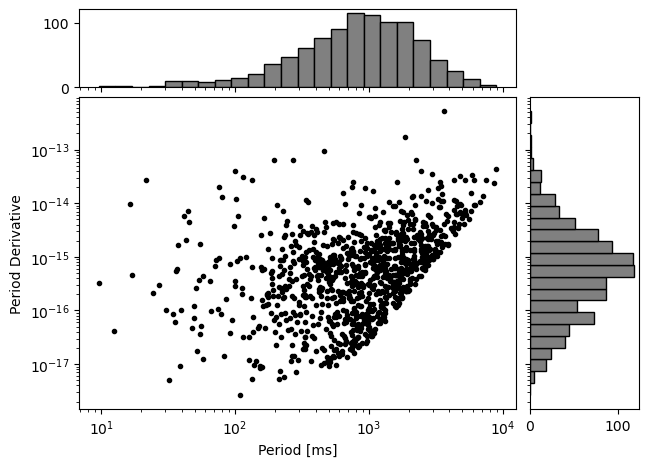

In [16]:

import matplotlib.pyplot as plt
x=periods
y=pdots


#making a histogram with scatter
def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x",labelbottom=False)
    ax_histy.tick_params(axis="y",labelleft=False)
    ax.set_xlabel('Period [ms]') 
    ax.set_ylabel('Period Derivative')
    ax.set_xscale('log')
    ax.set_yscale('log')


    # the scatter plot:
    ax.scatter(x, y,color='k',marker='.')

    # now determine nice limits by hand:
    binx=(np.logspace(np.log10(x.min()), np.log10(x.max()), num=25))
    biny=(np.logspace(np.log10(y.min()), np.log10(y.max()), num=25))
    ax_histx.hist(x, ec="black",bins=binx,color='grey')
    ax_histy.hist(y, orientation='horizontal',ec="black",bins=biny,color='grey')
    
# Start with a square Figure.
fig = plt.figure(figsize=(7, 5))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal axes and the main axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

# Draw the scatter plot and marginals.
scatter_hist(x, y, ax, ax_histx, ax_histy)
plt.savefig('p-pdot.png');plt.show();plt.close()

In [14]:
import dosurvey
import time
# 1. Capture the start time
start_time = time.perf_counter()

# 2. Run the target function

surveyPops = run(
    pop,
    surveys_list,
)
# 3. Capture the end time and calculate elapsed seconds
end_time = time.perf_counter()
elapsed = end_time - start_time

print(f"Execution time: {elapsed:.6f} seconds")

Running doSurvey on population...


Running survey AODRIFT
Total pulsars in model = 10000
Number detected by survey AODRIFT = 0
Of which are discoveries = 0
Number too faint = 827
Number smeared = 337
Number out = 8836



Running survey PALFA3
Total pulsars in model = 10000
Number detected by survey PALFA3 = 121
Of which are discoveries = 2
Number too faint = 1154
Number smeared = 10
Number out = 8715


Execution time: 0.153670 seconds


In [1]:
class Detections:
    """Just a simple object to store survey detection summary"""
    def __init__(self,
                 ndet=None,
                 ndisc=None,
                 nsmear=None,
                 nout=None,
                 nbr=None,
                 ntf=None):
        self.ndet = ndet
        self.ndisc = ndisc
        self.nsmear = nsmear
        self.nout = nout
        self.nbr = nbr
        self.nfaint = ntf



def write(surveyPops,
          extension='.results',
          nores=False,
          asc=False,
          summary=False):
    """Write a survey results population to a binary file."""

    for surv, survpop, detected in surveyPops:
        # create an output file, if required
        if not nores:
            if surv is not None:
                s = ''.join([surv, extension])

                survpop.write(s)
            else:
                s = 'allsurveys.results'
                survpop.write(s)

        # Write ascii file if required
        if asc and surv is not None:
            survpop.write_asc(surv + '.det')

        if summary and surv is not None:
            # Write a summary file for the survey (if true)
            filename = ''.join([surv, '.summary'])
            s = 'Detected {0}'.format(detected.ndet)
            s = '\n'.join([s, 'Ndiscovered {0}'.format(detected.ndisc)])
            s = '\n'.join([s, 'Nsmear {0}'.format(detected.nsmear)])
            s = '\n'.join([s, 'Nfaint {0}'.format(detected.nfaint)])
            s = '\n'.join([s, 'Nout {0}'.format(detected.nout)])
            s = '\n'.join([s, 'Nbr {0}'.format(detected.nbr)])
            s = ''.join([s, '\n'])

            with open(filename, 'w') as output:
                output.write(s)


def run(pop,
        surveyList,
        nostdout=False,
        allsurveyfile=False,
        scint=False,
        accelsearch=False,
        jerksearch=False,
        rratssearch=False):

    """ Run the surveys and detect the pulsars."""

    # print the population
    if not nostdout:
        print("Running doSurvey on population...")
        print(pop)

    # loop over the surveys we want to run on the pop file
    surveyPops = []
    for surv in surveyList:
        s = Survey(surv)
        s.discoveries = 0
        if not nostdout:
            print("\nRunning survey {0}".format(surv))

        # create a new population object to store discovered pulsars in
        survpop = Population()
        # HERE SHOULD INCLUDE THE PROPERTIES OF THE ORIGINAL POPULATION

        # counters
        nsmear = 0
        nout = 0
        ntf = 0
        ndet = 0
        nbr = 0
        # loop over the pulsars in the population list
        alive = [psr for psr in pop.population if not psr.dead]

        for psr in alive:

        
            # is the pulsar over the detection threshold?
            snr = s.SNRcalc(psr, pop,accelsearch,jerksearch,rratssearch)
            #print snr

            # add scintillation, if required
            # modifying S/N rather than flux is sensible because then
            # a pulsar can have same flux but change S/N in repeated surveys
            if scint:
                snr = s.scint(psr, snr)

            if snr > s.SNRlimit:
                ndet += 1
                psr.snr = snr
                survpop.population.append(psr)

                # check if the pulsar has been detected in other
                # surveys
                if not psr.detected:
                    # if not, set to detected and increment
                    # number of discoveries by the survey
                    psr.detected = True
                    s.discoveries += 1

            elif snr == -1.0:
                nsmear += 1
            elif snr == -2.0:
                nout += 1
            elif snr == -3.0:
                nbr += 1
            else:
                ntf += 1

        # report the results
        if not nostdout:
            print("Total pulsars in model = {0}".format(len(pop.population)))
            print("Number detected by survey {0} = {1}".format(surv, ndet))
            print("Of which are discoveries = {0}".format(s.discoveries))
            print("Number too faint = {0}".format(ntf))
            print("Number smeared = {0}".format(nsmear))
            print("Number out = {0}".format(nout))
            if rratssearch:
                print("Number didn't burst = {0}".format(nbr))
            print("\n")

        d = Detections(ndet=ndet,
                       ntf=ntf,
                       nsmear=nsmear,
                       nout=nout,
                       nbr=nbr,
                       ndisc=s.discoveries)
        surveyPops.append([surv, survpop, d])

    if allsurveyfile:
        allsurvpop = Population()
        allsurvpop.population = [psr for psr in pop.population if psr.detected]
        surveyPops.append([None, allsurvpop, None])

    return surveyPops


if __name__ == '__main__':
    """ 'Main' function; read in options, then survey the population"""
    # Parse command line arguments

    parser = argparse.ArgumentParser(
        description='Run a survey on your population model')
    parser.add_argument(
        '-f', metavar='fname', default='populate.model',
        help='file containing population model (def=populate.model')

    parser.add_argument(
        '-surveys', metavar='S', nargs='+', required=True,
        help='surveys to use to detect pulsars (required)')

    parser.add_argument(
        '--noresults', nargs='?', const=True, default=False,
        help='flag to switch off pickled .results file (def=False)')
    parser.add_argument(
        '--singlepulse', nargs='?', const=True, default=False,
        help='Rotating Radio Transients uses single pulse snr')

    parser.add_argument(
        '--asc', nargs='?', const=True, default=False,
        help='flag to create ascii population file (def=False)')

    parser.add_argument(
        '--summary', nargs='?', const=True, default=False,
        help='flag to create ascii summary file (def=False)')

    parser.add_argument(
        '--nostdout', nargs='?', const=True, default=False,
        help='flag to switch off std output (def=False)')

    parser.add_argument(
        '--allsurveys', nargs='?', const=True, default=False,
        help='write additional allsurv.results file (def=False)')

    parser.add_argument(
        '--scint', nargs='?', const=True, default=False,
        help='include model scintillation effects (def=False)')

    parser.add_argument(
        '--accel', nargs='?', const=True, default=False,
        help='use accel search for MSPs (def=False)')

    parser.add_argument(
        '--jerk', nargs='?', const=True, default=False,
        help='use accel & jerk search for MSPs (def=False)')

    args = parser.parse_args()

    # Load a model population
    population = loadModel(popfile=args.f)
    # run the population through the surveys
    surveyPopulations = run(population,
                            args.surveys,
                            nostdout=args.nostdout,
                            allsurveyfile=args.allsurveys,
                            scint=args.scint,
                            accelsearch=args.accel,
                            jerksearch=args.jerk,
                            rratssearch=args.singlepulse)

    # write the output files
    write(surveyPopulations,
          nores=args.noresults,
          asc=args.asc,
          summary=args.summary)

NameError: name 'argparse' is not defined